# Dropout and Batch Normalization

Cuando hablamos de capas en DL, tambien hay mas capas ademas de las **dense layers**. Existen varios tipos de capas con las que podemos complementar nuestra red neuronal, como las capas **dropout** (dropout layers).

## Dropout layers

Las capas de abandono (dropout) son capas que ayudan a regularizar la generalizacion con la que aprenden las redes nuronales. Lo que hace en si esta tecnica es que **Dropout** apaga aleatoriamente algunas de sus neuronas para no depender de unas cuantas. Hay que entender las neuronas como jugadores, si hacemos que el juego dependa de un solo jugador entonces los otros jugadores no trabajaran como deben y por lo tanto la prediccion no sera muy acertada.

## Batch Normalitation (Normalizacion por lotes)

Tambien llamada **Batchnorm**, es una capa que optimiza los inputs de entrenamiento. Es usual que para hacer una mejor prediccion hagamos que todos nuestros datos se encuentren en el mismo rango de numeros. Esto es asi ya que normalizar las columnas para nuestra red de neuronas tiene un impacto en el peso de las mismas.

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

red_wine = pd.read_csv("data/red-wine.csv")

df_train = red_wine.sample(frac = 0.7, random_state = 0)
df_valid = red_wine.drop(df_train.index)

X_train = df_train.drop('quality', axis = 1)
X_valid = df_valid.drop('quality', axis = 1)
y_train = df_train['quality']
y_valid = df_valid['quality']

In [9]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(1024, activation='relu', input_shape=[11]),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(1),
])

C:\Users\CDWLu\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


<Axes: >

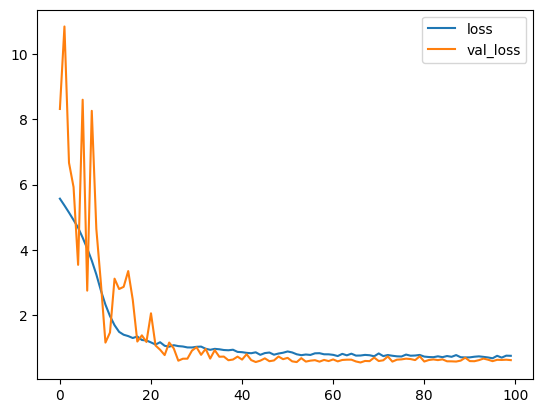

In [10]:
model.compile(
    optimizer = 'adam',
    loss = 'mae'
)

history = model.fit(
    X_train, y_train,
    validation_data = (X_valid, y_valid),
    batch_size = 256,
    epochs = 100,
    verbose = 0,
)

history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot()